<a href="https://colab.research.google.com/github/sofa-tsy/LMS-ML-/blob/main/kNN_LMS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**!!!!!!!!!!Нужно приложить фаайл k_nearest_neighbor.py чтобы заработал код**

# k-Nearest Neighbor (kNN) implementation

*Credits: this notebook is deeply based on Stanford CS231n course assignment 1. Source link: http://cs231n.github.io/assignments2019/assignment1/*

The kNN classifier consists of two stages:

- During training, the classifier takes the training data and simply remembers it
- During testing, kNN classifies every test image by comparing to all training images and transfering the labels of the k most similar training examples
- The value of k is cross-validated

In this exercise you will implement these steps and understand the basic Image Classification pipeline and gain proficiency in writing efficient, vectorized code.

We will work with the handwritten digits dataset. Images will be flattened (8x8 sized image -> 64 sized vector) and treated as vectors.

In [ ]:
'''
If you are using Google Colab, uncomment the next line to download `k_nearest_neighbor.py`.
You can open and change it in Colab using the "Files" sidebar on the left.
'''
# !wget https://raw.githubusercontent.com/girafe-ai/ml-course/23s_dd_ml/homeworks/assignment0_01_knn/k_nearest_neighbor.py

'\nIf you are using Google Colab, uncomment the next line to download `k_nearest_neighbor.py`.\nYou can open and change it in Colab using the "Files" sidebar on the left.\n'

In [ ]:
from sklearn import datasets
dataset = datasets.load_digits()
print(dataset.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

.. _digits_dataset:

Набор данных для оптического распознавания рукописных цифр
--------------------------------------------------

**Характеристики набора данных:**

:Количество экземпляров: 1797
:Количество атрибутов: 64
:Информация об атрибутах: изображение размером 8x8 целых пикселей в диапазоне 0..16.
:Отсутствующие значения атрибутов: Отсутствуют
:Автор: Э. Алпайдин (alpaydin '@' boun.edu.tr)
:Дата: июль 1998 г.

Это копия тестового набора наборов рукописных цифр UCI ML.
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

Набор данных содержит изображения рукописных цифр: 10 классов, где
каждый класс относится к определенной цифре.

Программы предварительной обработки, доступные в NIST, использовались для извлечения
нормализованных растровых изображений рукописных цифр из предварительно напечатанной формы. Из
общего числа 43 человек 30 приняли участие в тренировочном наборе и 13
- в тестовом. Растровые изображения размером 32х32 разбиты на неперекрывающиеся блоки размером
4х4, и в каждом блоке подсчитывается количество пикселей. Это генерирует
входную матрицу размером 8x8, где каждый элемент является целым числом в диапазоне
0..16. Это уменьшает размерность и обеспечивает инвариантность для небольших
искажения.

Для получения информации о процедурах предварительной обработки NIST обратитесь к М. Д. Гаррису, Дж. Л. Блю, Г.
Т. Канделе, Д. Л. Диммику, Дж. Гейсту, П. Дж. Гротеру, С. А. Джанет и К.
Л. Уилсон, Система распознавания отпечатков рук на основе форм NIST, NISTIR 5469,
1994.

.. список использованной литературы

  - С. Кайнак (1995) Методы объединения нескольких классификаторов и их
    Приложения для распознавания рукописных цифр, магистерская диссертация, Институт
    Аспирантуры в области науки и техники, Университет Богазичи.
  - Э. Алпайдин, К. Кайнак (1998) Каскадные классификаторы, Кибернетика.
  - Кен Тан и Поннутурай, Н. Сугантан, Си Яо и А. Кай Цинь.
    Линейное уменьшение размерности с использованием LDA, взвешенного по релевантности. Школа
    Наньянский технологический университет электротехники и электроники.
    2005.
  - Клаудио Джентиле. Новая приблизительная классификация максимальной маржи
    Алгоритм. ЩИПЛЕТ. 2000.

In [ ]:
# First 100 images will be used for testing. This dataset is not sorted by the labels, so it's ok
# to do the split this way.
# Please be careful when you split your data into train and test in general.
test_border = 100
X_train, y_train = dataset.data[test_border:], dataset.target[test_border:]
X_test, y_test = dataset.data[:test_border], dataset.target[:test_border]

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
num_test = X_test.shape[0]

Training data shape:  (1697, 64)
Training labels shape:  (1697,)
Test data shape:  (100, 64)
Test labels shape:  (100,)


In [ ]:
pip install ipython

In [ ]:
# Установка совместимых версий
!pip install ipython==8.22.2
!pip install numpy==1.24.3

# Перезапустите ядро после установки
import os
os.kill(os.getpid(), 9)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 812.0/812.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 9.9 MB/s eta 0:00:00
  Attempting uninstall: traitlets
    Found existing installation: traitlets 5.7.1
    Uninstalling traitlets-5.7.1:
      Successfully uninstalled traitlets-5.7.1
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 8.22.2 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 60.0 MB/s eta 0:00:00
^C


In [ ]:
# Run some setup code for this notebook.
import random
import numpy as np
import matplotlib.pyplot as plt

# This is a bit of magic to make matplotlib figures appear inline in the notebook
# rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (14.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

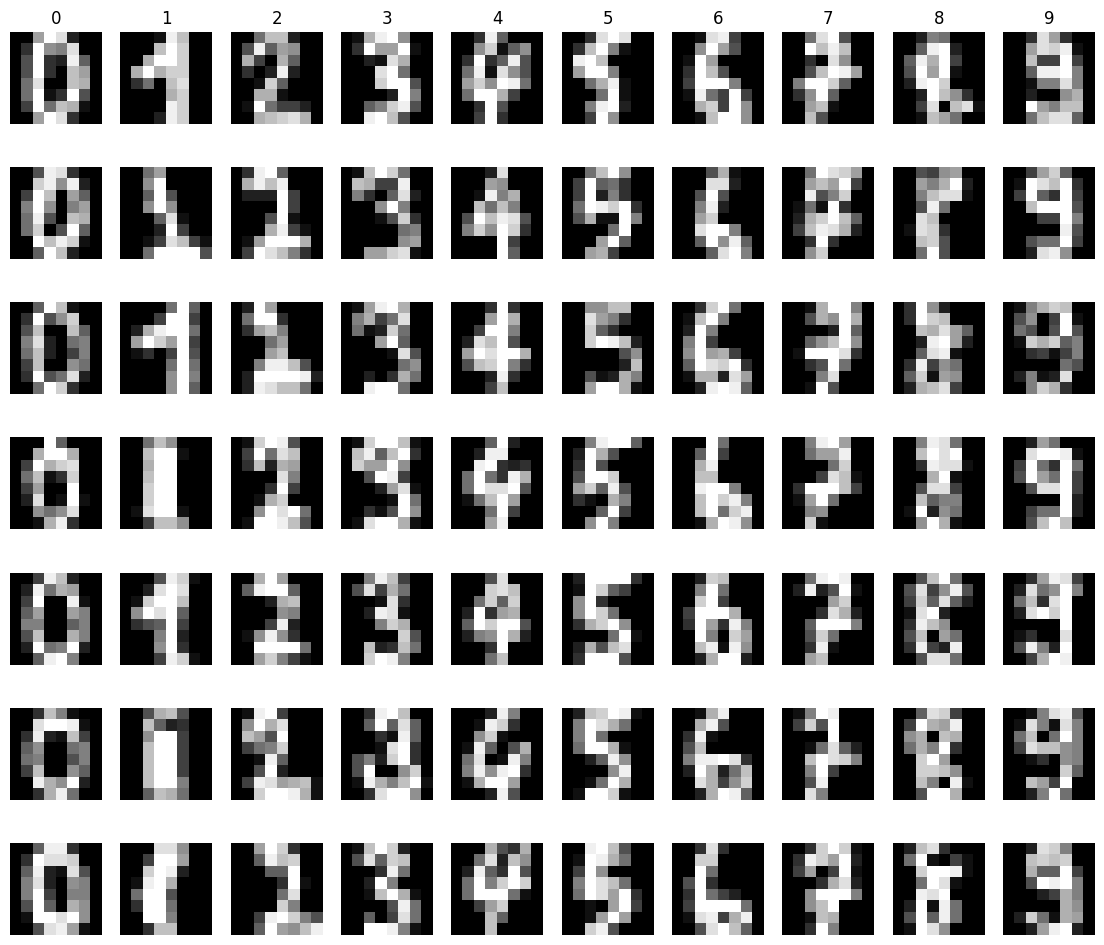

In [ ]:
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = list(np.arange(10))
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].reshape((8, 8)).astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

Autoreload is a great stuff, but sometimes it does not work as intended. The code below aims to fix than. __Do not forget to save your changes in the `.py` file before reloading the `KNearestNeighbor` class.__


Автозагрузка - отличная штука, но иногда она работает не так, как задумывалось. Приведенный ниже код призван исправить это. __ Не забудьте сохранить изменения в файле `.py` перед перезагрузкой класса `KNearestNeighbor`.__

In [ ]:
# This dirty hack might help if the autoreload has failed for some reason
try:
    del KNearestNeighbor
except:
    pass

from k_nearest_neighbor import KNearestNeighbor

# Create a kNN classifier instance.
# Remember that training a kNN classifier is a noop:
# the Classifier simply remembers the data and does no further processing
classifier = KNearestNeighbor()
classifier.fit(X_train, y_train)

In [ ]:
X_train.shape

(1697, 64)

We would now like to classify the test data with the kNN classifier. Recall that we can break down this process into two steps:

1. First we must compute the distances between all test examples and all train examples.
2. Given these distances, for each test example we find the k nearest examples and have them vote for the label

Lets begin with computing the distance matrix between all training and test examples. For example, if there are **Ntr** training examples and **Nte** test examples, this stage should result in a **Nte x Ntr** matrix where each element (i,j) is the distance between the i-th test and j-th train example.

**Note: For the three distance computations that we require you to implement in this notebook, you may not use the np.linalg.norm() function that numpy provides.**

First, open `k_nearest_neighbor.py` and implement the function `compute_distances_two_loops` that uses a (very inefficient) double loop over all pairs of (test, train) examples and computes the distance matrix one element at a time.

In [ ]:
# Open k_nearest_neighbor.py and implement
# compute_distances_two_loops.

# Test your implementation:
dists = classifier.compute_distances_two_loops(X_test)
print(dists.shape)

(100, 1697)


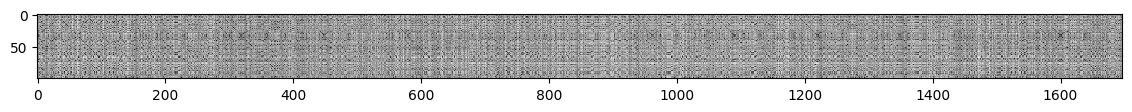

In [ ]:
# We can visualize the distance matrix: each row is a single test example and
# its distances to training examples
plt.imshow(dists, interpolation='none')
plt.show()

**Inline Question 1**

Notice the structured patterns in the distance matrix, where some rows or columns are visible brighter. (Note that with the default color scheme black indicates low distances while white indicates high distances.)

- What in the data is the cause behind the distinctly bright rows?
- What causes the columns?

$\color{blue}{\textit Your Answer:}$ *fill this in.*



In [ ]:
# Now implement the function predict_labels and run the code below:
# We use k = 1 (which is Nearest Neighbor).
y_test_pred = classifier.predict_labels(dists, k=1)

# Compute and print the fraction of correctly predicted examples
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 95 / 100 correct => accuracy: 0.950000


You should expect to see approximately `95%` accuracy. Now lets try out a larger `k`, say `k = 5`:

In [ ]:
y_test_pred = classifier.predict_labels(dists, k=5)
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 93 / 100 correct => accuracy: 0.930000


Accuracy should slightly decrease with `k = 5` compared to `k = 1`.

**Inline Question 2**

We can also use other distance metrics such as L1 distance.
For pixel values $p_{ij}^{(k)}$ at location $(i,j)$ of some image $I_k$,

the mean $\mu$ across all pixels over all images is $$\mu=\frac{1}{nhw}\sum_{k=1}^n\sum_{i=1}^{h}\sum_{j=1}^{w}p_{ij}^{(k)}$$
And the pixel-wise mean $\mu_{ij}$ across all images is
$$\mu_{ij}=\frac{1}{n}\sum_{k=1}^np_{ij}^{(k)}.$$
The general standard deviation $\sigma$ and pixel-wise standard deviation $\sigma_{ij}$ is defined similarly.

Which of the following preprocessing steps will not change the performance of a Nearest Neighbor classifier that uses L1 distance? Select all that apply.
1. Subtracting the mean $\mu$ ($\tilde{p}_{ij}^{(k)}=p_{ij}^{(k)}-\mu$.)
2. Subtracting the per pixel mean $\mu_{ij}$  ($\tilde{p}_{ij}^{(k)}=p_{ij}^{(k)}-\mu_{ij}$.)
3. Subtracting the mean $\mu$ and dividing by the standard deviation $\sigma$.
4. Subtracting the pixel-wise mean $\mu_{ij}$ and dividing by the pixel-wise standard deviation $\sigma_{ij}$.
5. Rotating the coordinate axes of the data.

$\color{blue}{\textit Your Answer:}$


$\color{blue}{\textit Your Explanation:}$


1. Subtracting the mean μ (вычитание общего среднего) ✅ НЕ меняет производительность

$|(p_{ij}^{(k)} - \mu) - (p_{ij}^{(l)} - \mu)| = |p_{ij}^{(k)} - p_{ij}^{(l)}|$

2. Subtracting the per pixel mean μᵢⱼ (вычитание попиксельного среднего) ✅ НЕ меняет производительность

$|(p_{ij}^{(k)} - \mu_{ij}) - (p_{ij}^{(l)} - \mu_{ij})| = |p_{ij}^{(k)} - p_{ij}^{(l)}|$

$|\frac{p_{ij}^{(k)} - \mu}{\sigma} - \frac{p_{ij}^{(l)} - \mu}{\sigma}| = \frac{1}{\sigma}\sum |p_{ij}^{(k)} - p_{ij}^{(l)}|$

$\sum |\frac{p_{ij}^{(k)} - \mu_{ij}}{\sigma_{ij}} - \frac{p_{ij}^{(l)} - \mu_{ij}}{\sigma_{ij}}| = \sum \frac{1}{\sigma_{ij}} |p_{ij}^{(k)} - p_{ij}^{(l)}|$

In [ ]:
# Now lets speed up distance matrix computation by using partial vectorization
# with one loop. Implement the function compute_distances_one_loop and run the
# code below:
dists_one = classifier.compute_distances_one_loop(X_test)

# To ensure that our vectorized implementation is correct, we make sure that it
# agrees with the naive implementation. There are many ways to decide whether
# two matrices are similar; one of the simplest is the Frobenius norm. In case
# you haven't seen it before, the Frobenius norm of two matrices is the square
# root of the squared sum of differences of all elements; in other words, reshape
# the matrices into vectors and compute the Euclidean distance between them.
difference = np.linalg.norm(dists - dists_one, ord='fro')
print('One loop difference was: %f' % (difference, ))
if difference < 0.001:
    print('Good! The distance matrices are the same')
else:
    print('Uh-oh! The distance matrices are different')

One loop difference was: 0.000000
Good! The distance matrices are the same


In [ ]:
# Now implement the fully vectorized version inside compute_distances_no_loops
# and run the code
dists_two = classifier.compute_distances_no_loops(X_test)

# check that the distance matrix agrees with the one we computed before:
difference = np.linalg.norm(dists - dists_two, ord='fro')
print('No loop difference was: %f' % (difference, ))
if difference < 0.001:
    print('Good! The distance matrices are the same')
else:
    print('Uh-oh! The distance matrices are different')

No loop difference was: 0.000000
Good! The distance matrices are the same


### Comparing handcrafted and `sklearn` implementations
In this section we will just compare the performance of handcrafted and `sklearn` kNN algorithms. The predictions should be the same. No need to write any code in this section.

In [ ]:
from sklearn import neighbors

In [ ]:
implemented_knn = KNearestNeighbor()
implemented_knn.fit(X_train, y_train)

In [ ]:
n_neighbors = 1
external_knn = neighbors.KNeighborsClassifier(n_neighbors=n_neighbors)
external_knn.fit(X_train, y_train)
print('sklearn kNN (k=1) implementation achieves: {} accuracy on the test set'.format(
    external_knn.score(X_test, y_test)
))
y_predicted = implemented_knn.predict(X_test, k=n_neighbors).astype(int)
accuracy_score = sum((y_predicted==y_test).astype(float)) / num_test
print('Handcrafted kNN (k=1) implementation achieves: {} accuracy on the test set'.format(accuracy_score))
assert np.array_equal(
    external_knn.predict(X_test),
    y_predicted
), 'Labels predicted by handcrafted and sklearn kNN implementations are different!'
print('\nsklearn and handcrafted kNN implementations provide same predictions')
print('_'*76)


n_neighbors = 5
external_knn = neighbors.KNeighborsClassifier(n_neighbors=n_neighbors)
external_knn.fit(X_train, y_train)
print('sklearn kNN (k=5) implementation achieves: {} accuracy on the test set'.format(
    external_knn.score(X_test, y_test)
))
y_predicted = implemented_knn.predict(X_test, k=n_neighbors).astype(int)
accuracy_score = sum((y_predicted==y_test).astype(float)) / num_test
print('Handcrafted kNN (k=5) implementation achieves: {} accuracy on the test set'.format(accuracy_score))
assert np.array_equal(
    external_knn.predict(X_test),
    y_predicted
), 'Labels predicted by handcrafted and sklearn kNN implementations are different!'
print('\nsklearn and handcrafted kNN implementations provide same predictions')
print('_'*76)



sklearn kNN (k=1) implementation achieves: 0.95 accuracy on the test set
Handcrafted kNN (k=1) implementation achieves: 0.95 accuracy on the test set

sklearn and handcrafted kNN implementations provide same predictions
____________________________________________________________________________
sklearn kNN (k=5) implementation achieves: 0.93 accuracy on the test set
Handcrafted kNN (k=5) implementation achieves: 0.93 accuracy on the test set

sklearn and handcrafted kNN implementations provide same predictions
____________________________________________________________________________


### Measuring the time
Finally let's compare how fast the implementations are.

To make the difference more noticable, let's repeat the train and test objects (there is no point but to compute the distance between more pairs).

In [ ]:
X_train_big = np.vstack([X_train]*5)
X_test_big = np.vstack([X_test]*5)
y_train_big = np.hstack([y_train]*5)
y_test_big = np.hstack([y_test]*5)

In [ ]:
classifier_big = KNearestNeighbor()
classifier_big.fit(X_train_big, y_train_big)
# Let's compare how fast the implementations are
def time_function(f, *args):
    """
    Call a function f with args and return the time (in seconds) that it took to execute.
    """
    import time
    tic = time.time()
    f(*args)
    toc = time.time()
    return toc - tic

two_loop_time = time_function(classifier_big.compute_distances_two_loops, X_test_big)
print('Two loop version took %f seconds' % two_loop_time)

one_loop_time = time_function(classifier_big.compute_distances_one_loop, X_test_big)
print('One loop version took %f seconds' % one_loop_time)

no_loop_time = time_function(classifier_big.compute_distances_no_loops, X_test_big)
print('No loop version took %f seconds' % no_loop_time)

# You should see significantly faster performance with the fully vectorized implementation!

# NOTE: depending on what machine you're using,
# you might not see a speedup when you go from two loops to one loop,
# and might even see a slow-down.

Two loop version took 17.419746 seconds
One loop version took 0.391422 seconds
No loop version took 0.055519 seconds


The improvement seems significant. (On some hardware one loop version may take even more time, than two loop, but no loop should definitely be the fastest.

**Inline Question 3**

Which of the following statements about $k$-Nearest Neighbor ($k$-NN) are true in a classification setting, and for all $k$? Select all that apply.
1. The decision boundary (hyperplane between classes in feature space) of the k-NN classifier is linear.
2. The training error of a 1-NN will always be lower than that of 5-NN.
3. The test error of a 1-NN will always be lower than that of a 5-NN.
4. The time needed to classify a test example with the k-NN classifier grows with the size of the training set.
5. None of the above.

$\color{blue}{\textit Your Answer:}$


$\color{blue}{\textit Your Explanation:}$



Congratulations! Please, submit the .py file to the contest system.

**1. The decision boundary of the k-NN classifier is linear.** ❌ **Ложь**
- Граница решения kNN не является линейной в общем случае
- kNN создает **кусочно-линейную** (piecewise-linear) границу, которая может быть очень сложной и нелинейной
- Граница формируется областями Вороного (Voronoi tessellation) вокруг тренировочных точек
- Чем больше k, тем более сглаженной становится граница, но она всё равно остается нелинейной

**2. The training error of a 1-NN will always be lower than that of 5-NN.** ✅ **Истина**
- При k=1 каждый тренировочный образец является своим собственным ближайшим соседом
- Следовательно, на тренировочных данных ошибка 1-NN **всегда равна 0** (идеальное запоминание)
- При k=5 возможны ошибки на тренировочных данных, так как голосование 5 соседей может дать неверный результат
- Таким образом, training error(1-NN) ≤ training error(5-NN) для любого набора данных

**3. The test error of a 1-NN will always be lower than that of a 5-NN.** ❌ **Ложь**
- Это не всегда верно! 1-NN склонен к **переобучению** (overfitting)
- 1-NN чувствителен к шуму и выбросам в данных
- Большие значения k могут давать лучшее обобщение, сглаживая шум
- Часто оптимальное k > 1 дает меньшую тестовую ошибку
- Зависит от конкретного набора данных

**4. The time needed to classify a test example with the k-NN classifier grows with the size of the training set.** ✅ **Истина**
- В наивной реализации kNN требует вычисления расстояния до **каждого** тренировочного образца
- Сложность классификации одного тестового примера: O(n), где n - размер обучающей выборки
- При увеличении тренировочного набора время классификации **линейно растет**
- (Существуют оптимизации, но в общем случае это верно)

**5. None of the above.** ❌ **Ложь**
- Так как утверждения 2 и 4 верны, этот вариант не подходит



# Альтернативное задание

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('health care diabetes.csv')

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
y = df.iloc[:,-1]
y.value_counts(normalize=True)

,proportion
Outcome,
0,0.651042
1,0.348958


Variables Description

• Pregnancies Number of times pregnant

• Glucose Plasma glucose concentration in an oral glucose tolerance test

• BloodPressure Diastolic blood pressure (mm Hg)

• SkinThickness Triceps skinfold thickness (mm)

• Insulin Two-hour serum insulin

• BMI Body Mass Index

• DiabetesPedigreeFunction Diabetes pedigree function

• Age Age in years

• Outcome Class variable (either 0 or 1). 268 of 768 values are 1, and the others are 0

Задача: Как часто болеют диабетом?

In [ ]:
round(df[df['Outcome']==1].shape[0]/(df[df['Outcome']==1].shape[0] + df[df['Outcome']==0].shape[0]),2)

0.35

Выполните анализ и предобработку данных. Рассчитайте разность по модулю между средними значением кровяного давления для больных диабетом и здоровых пациентов.

Ответ необходимо ввести без размерности и с округлением до сотых.

In [ ]:
av_blood_0 = df[df['Outcome']==0]['BloodPressure'].mean()
av_blood_1 = df[df['Outcome']==1]['BloodPressure'].mean()
print(round(av_blood_1-av_blood_0,2))

2.64


Какие признаки, скорее всего, будут информативными исходя из проведенного анализа? Есть ли проблема мультиколлинеарности признаков? В качестве ответа введите названия нецелевых признаков (в алфавитном порядке) между  которыми наибольший коэффициент корреляции.

Название признаков записываете как в исходном датасете в одной строке через пробел.

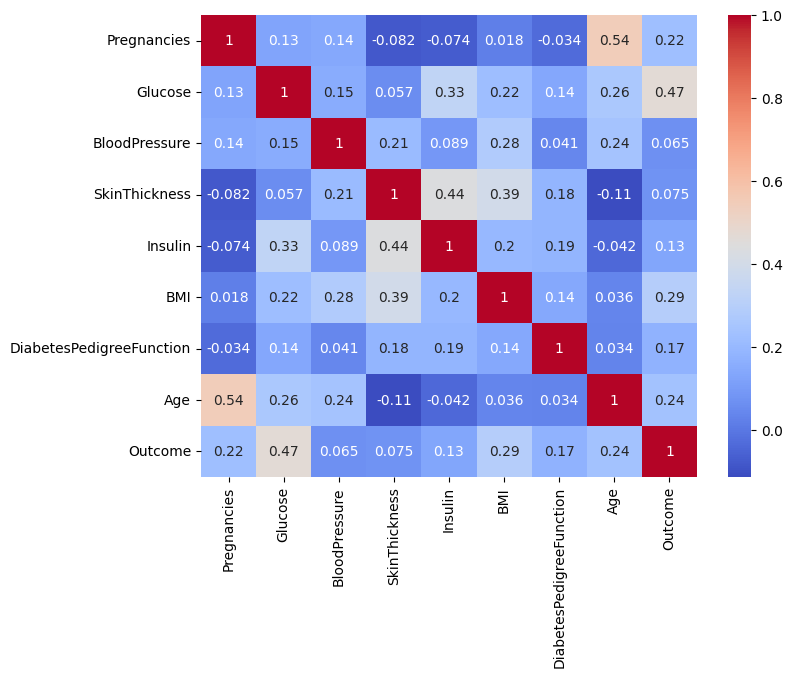

In [ ]:
plt.figure(figsize= (8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Ответ Age, Pregnancies - 0.54

Используя взаимную информацию оцените значимость признаков. Рассчитать взаимную информацию можно с помощью функции sklearn (https://scikit-learn.org/1.5/modules/generated/sklearn.feature_selection.mutual_info_classif.html).

В качестве ответа введите название признака для которого этот показатель максимален.

In [ ]:
from sklearn.feature_selection import mutual_info_classif
arr = mutual_info_classif( df.iloc[:, :-1] , df['Outcome'])

print(arr)
val_max = arr.max()
print(val_max)
ind_max = arr.argmax()
print(ind_max)

print( df.columns[ind_max])

# насколько сильно каждый признак (например, уровень глюкозы, возраст, давление) влияет на возможность предсказать нашу цель
#  (есть диабет или нет).

[0.03186519 0.10650533 0.00113128 0.00901971 0.05296884 0.08682625
 0.0100306  0.06723656]
0.10650532845888327
1
Glucose


Болен или не болен диабетом?

Постройте модель knn для предсказания того болен человек диабетом или нет. Для этого используйте данные по заболеваемости диабетом (https://www.kaggle.com/datasets/gyanashish/healthcare-diabetes).

При обучении модели разделите данные на обучающую и тестовую части в соотношении 80:20. Зафиксируйте random_state равным 42 (при разделении данных и кросс-валидации). В кросс-валидации используйте перемешивание объектов (параметр shuffle) и KFold (https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.KFold.html).

Подбор гиперпараметров реализуйте с помощью GridSearchCV (рассматриваете число ближайших соседей от 3 до 20 (включительно) и метрики 'minkowski', 'euclidean', 'cosine').

В качестве ответа введите подобранные гиперпараметры (сначала метрику, а потом через пробел оптимальное число ближайших соседей).

In [ ]:
# preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split # разделение на обучающую и тестовую выборки
from sklearn.model_selection import GridSearchCV #подбор гиперпараметров методом сетки
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
# from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline

y = df.iloc[:,-1].values
x = df.iloc[:, :-1].values

print('X', x.shape)
print('Y', y.shape)

# scaler = MinMaxScaler()
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

print('x_train', x_train.shape)
print('x_test', x_test.shape)
print('y_train', y_train.shape)
print('y_test', y_test.shape)


# pipe = Pipeline([
#     ('scaler', StandardScaler() ),
#     ('knn', KNeighborsRegressor())
# ])

knn = KNeighborsClassifier()


kfold = KFold(n_splits=5, shuffle=True, random_state=42)
#  KFold создает объект-итератор, который генерирует индексы для разделения данных на обучающую и тестовую выборки


param_grid = {
    'n_neighbors': list(range(3, 21)),          # от 3 до 20 включительно
    'metric': ['minkowski', 'euclidean', 'cosine']
}
# добавляется приставка knn, чтобы из pipe достать нужную функцию и именно У НЕЕ взять параметры и метрики


# метрики:
# minkowski - Корень степени p из суммы модулей разностей в степени p.
# euclidean - Корень из суммы квадратов разностей по каждому признаку.
# cosine - Эта метрика измеряет угол между векторами признаков, а не разницу в их длине. 1 минус косинус угла между векторами.



# GridSearchCV для автоматического подбора лучших гиперпараметров модели.
# Grid Search (поиск по сетке) + Cross-Validation (кросс-валидация).

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=kfold,               # используем настроенный KFold
    scoring='accuracy',     # можно выбрать другую метрику
    n_jobs=-1               # использовать все ядра процессора
)

# 8. Обучение
grid_search.fit(x_train, y_train)

print("Лучшие гиперпараметры, найденные GridSearchCV:")
print(grid_search.best_params_)

# Дополнительно: точность на тесте
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
test_accuracy = best_model.score(x_test, y_test)
print(f"Точность лучшей модели на тестовой выборке: {test_accuracy:.4f}")
# print(accuracy_score(y_test, y_pred))

X (768, 8)
Y (768,)
x_train (614, 8)
x_test (154, 8)
y_train (614,)
y_test (154,)
Лучшие гиперпараметры, найденные GridSearchCV:
{'metric': 'minkowski', 'n_neighbors': 11}
Точность лучшей модели на тестовой выборке: 0.7338


Обучите модель с подобранными в предыдущем задании оптимальными гиперпараметрами. Оцените качество обученной модели на тестовой части выборки (тестовая часть составляет 33%) по метрикам accuracy, precision, recall, f1-score и AUC ROC. Первые четыре метрики (с макроусреднением) рассчитывайте с помощью функции classification_report.

Зафиксируйте random_state равным 42 (при разделении данных).

В качестве ответа введите в одной строке через пробел полученные значения метрик (с округлением до сотых) для тестовой выборки в следующем порядке: accuracy, precision, recall, f1-score и AUC ROC.

Ответ в формате: 0.00 0.00 0.00 0.00

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.33, random_state = 42)

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Подставьте сюда значения metric и n_neighbors из предыдущего задания!
best_knn = KNeighborsClassifier(
    n_neighbors=11,        # замените на ваше оптимальное значение
    metric='minkowski'      # замените на вашу оптимальную метрику
)

best_knn.fit(x_train, y_train)

y_pred = best_knn.predict(x_test)

res = classification_report(y_test, y_pred)

print(res)
# печатает аккуратную табличку с основными показателями эффективности для каждого класса
# precision (точность)
# recall (полнота)
# f1-score (среднее гармоническое precision и recall)
# support (количество реальных примеров этого класса в выборке)

# Первый вариант устреднений метрик это-
# Макроусреднение — это когда вы берете среднее арифметическое этих двух чисел, не обращая внимания на то, что классы неравны по размеру
# Считает среднее арифметическое метрик для каждого класса, не учитывая, сколько объектов в каждом классе.

# Второй вариант это взвешенное устреднение
# Считает среднее арифметическое метрик для каждого класса, но умножает (взвешивает) каждую метрику на долю объектов этого класса в выборке


report = classification_report(y_test, y_pred, output_dict=True)
# тут нужен словарь, чтобы присвоить переменным значения из таблицы, а то без output_dict=True не получится

precision = report['macro avg']['precision']
recall = report['macro avg']['recall']
f1_score = report['macro avg']['f1-score']
accuravy = report['accuracy']

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision (macro): {precision:.2f}")
print(f"Recall (macro): {recall:.2f}")
print(f"F1-score (macro): {f1_score:.2f}")


# для AUC ROC нужны вероятности
y_pred_prob = best_knn.predict_proba(x_test)
# predict_proba метод, который возвращает вероятности принадлежности объекта к каждому классу

# print(y_pred_prob)
# Столбец 0: Вероятность того, что объект принадлежит к классу 0 (в вашем случае — "здоров").
# Столбец 1: Вероятность того, что объект принадлежит к классу 1 (в вашем случае — "болен").

# AUC ROC — вероятности положительного класса ("болен").
roc_auc = roc_auc_score( y_test, y_pred_prob[:,1])
print(f"AUC ROC: {roc_auc:.2f}")


print("\nОтвет в требуемом формате:")
print(f"{accuracy:.2f} {precision:.2f} {recall:.2f} {f1_score:.2f} {roc_auc:.2f}")

# 0.72(!!!!) 0.69 0.66 0.67 0.76

              precision    recall  f1-score   support

           0       0.76      0.85      0.80       168
           1       0.62      0.48      0.54        86

    accuracy                           0.72       254
   macro avg       0.69      0.66      0.67       254
weighted avg       0.71      0.72      0.71       254

Accuracy: 0.73
Precision (macro): 0.69
Recall (macro): 0.66
F1-score (macro): 0.67
AUC ROC: 0.76

Ответ в требуемом формате:
0.73 0.69 0.66 0.67 0.76


Проанализируйте как меняется качество модели при увеличении числа ближайших соседей. Начните с 2 ближайших соседей (рассмотрите значения до 15 включительно). Постройте графики изменения метрики precision с макроусреднением при увеличении числа учитываемых соседей.

Укажите оптимальное число ближайших соседей (по метрике precision с макроусреднением)на тестовой части выборки. Тестовая часть данных составляет 33% от исходной выборки. При разделении данных зафиксируйте random_state равным 42.

Ответ в формате: 11

Проанализируйте как меняется качество модели при увеличении числа ближайших соседей. Начните с 2 ближайших соседей (рассмотрите значения до 15 включительно). Постройте графики изменения метрики precision с макроусреднением при увеличении числа учитываемых соседей.

Укажите оптимальное число ближайших соседей (по метрике f1-score с макроусреднением)на тестовой части выборки. Тестовая часть данных составляет 33% от исходной выборки. При разделении данных зафиксируйте random_state равным 42.

Ответ в формате: 1

Проанализируйте как меняется качество модели при увеличении числа ближайших соседей. Начните с 2 ближайших соседей (рассмотрите значения до 15 включительно). Постройте графики изменения метрики precision с макроусреднением при увеличении числа учитываемых соседей.

Укажите оптимальное число ближайших соседей (по метрике recall с макроусреднением)на тестовой части выборки. Тестовая часть данных составляет 33% от исходной выборки. При разделении данных зафиксируйте random_state равным 42.

Ответ в формате: 1

Проанализируйте как меняется качество модели при увеличении числа ближайших соседей. Начните с 2 ближайших соседей (рассмотрите значения до 15 включительно). Постройте графики изменения метрики AUC ROC при увеличении числа учитываемых соседей.

Укажите оптимальное число ближайших соседей (по метрике AUC ROC) на тестовой части выборки. Тестовая часть данных составляет 33% от исходной выборки. При разделении данных зафиксируйте random_state равным 42.

Ответ в формате: 1



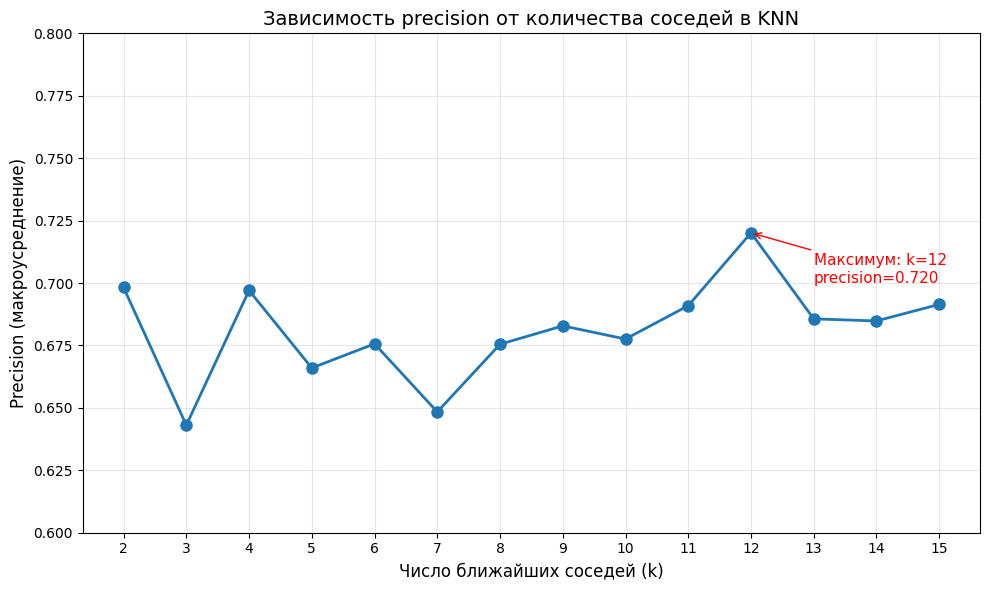

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.33, random_state = 42)

neighbors_range = range(2, 16)
precision = []
f_arr = []
recall_arr = []
roc = []

for i in neighbors_range:
  knn = KNeighborsClassifier( n_neighbors= i , metric= 'minkowski')
  knn.fit(x_train,y_train)

  y_pred_i = knn.predict(x_test)

  res = classification_report(y_test,y_pred_i, output_dict = True)
  pr = res['macro avg']['precision']
  f1_score = res['macro avg']['f1-score']
  recall = res['macro avg']['recall']

  y_pred_prob = knn.predict_proba(x_test)[:,1]
  roc_val = roc_auc_score(y_test, y_pred_prob)


  precision.append(pr)
  f_arr.append(f1_score)
  recall_arr.append(recall)
  roc.append(roc_val)

# print(precision)

plt.figure(figsize=(10, 6))
plt.plot(neighbors_range, precision, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.xlabel('Число ближайших соседей (k)', fontsize=12)
plt.ylabel('Precision (макроусреднение)', fontsize=12)
plt.title('Зависимость precision от количества соседей в KNN', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(neighbors_range)
plt.ylim(0.6, 0.8)

# Добавляем аннотацию с максимальным значением
max_precision = max(precision)
max_neighbor = neighbors_range[precision.index(max_precision)]
plt.annotate(f'Максимум: k={max_neighbor}\nprecision={max_precision:.3f}',
             xy=(max_neighbor, max_precision),
             xytext=(max_neighbor+1, max_precision-0.02),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=11,
             color='red')

plt.tight_layout()
plt.show()

0.6817264183780021
9


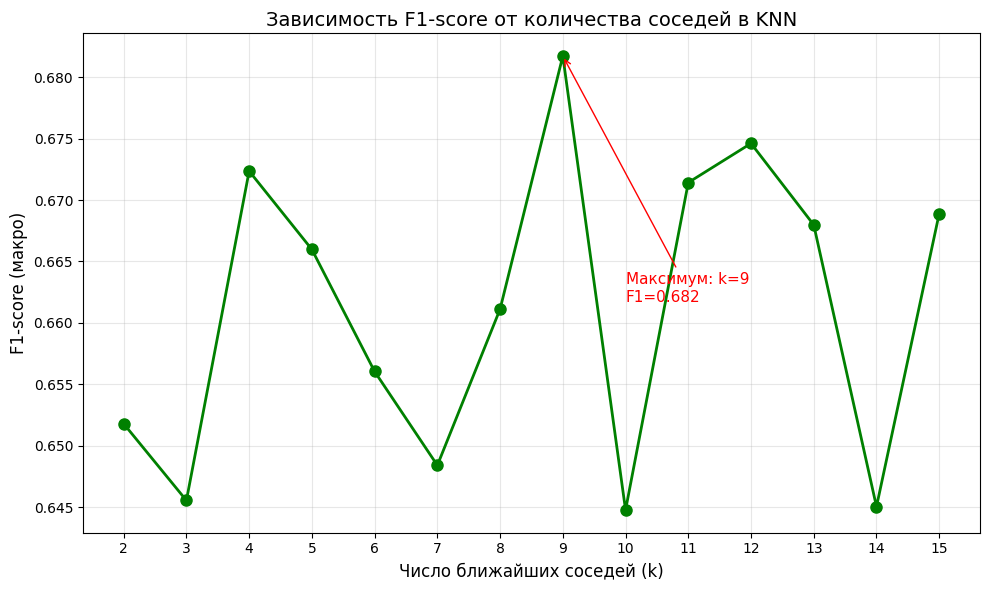

ОПТИМАЛЬНОЕ ЧИСЛО СОСЕДЕЙ (ПО F1-SCORE): 9
Максимальное значение F1-score (macro): 0.6817


In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(neighbors_range, f_arr, marker='o', linestyle='-',
         linewidth=2, markersize=8, color='green')
plt.xlabel('Число ближайших соседей (k)', fontsize=12)
plt.ylabel('F1-score (макро)', fontsize=12)
plt.title('Зависимость F1-score от количества соседей в KNN', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(neighbors_range)

# Находим максимум
max_f1 = max(f_arr)
print(max_f1)
max_neighbor = neighbors_range[f_arr.index(max_f1)]
print(max_neighbor)

plt.annotate(f'Максимум: k={max_neighbor}\nF1={max_f1:.3f}',
             xy=(max_neighbor, max_f1),
             xytext=(max_neighbor+1, max_f1-0.02),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=11,
             color='red')

plt.tight_layout()
plt.show()

print(f"ОПТИМАЛЬНОЕ ЧИСЛО СОСЕДЕЙ (ПО F1-SCORE): {max_neighbor}")
print(f"Максимальное значение F1-score (macro): {max_f1:.4f}")


Text(10, 0.6607170542635659, 'Максимум: k=9\nRecall=0.681')

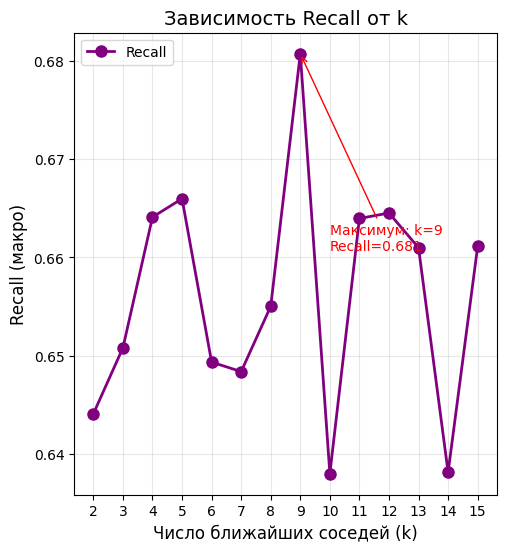

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(neighbors_range, recall_arr, marker='o', linestyle='-',
         linewidth=2, markersize=8, color='purple', label='Recall')
plt.xlabel('Число ближайших соседей (k)', fontsize=12)
plt.ylabel('Recall (макро)', fontsize=12)
plt.title('Зависимость Recall от k', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(neighbors_range)
plt.legend()

# Находим максимум
max_recall = max(recall_arr)
max_neighbor = neighbors_range[recall_arr.index(max_recall)]

plt.annotate(f'Максимум: k={max_neighbor}\nRecall={max_recall:.3f}',
             xy=(max_neighbor, max_recall),
             xytext=(max_neighbor+1, max_recall-0.02),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10,
             color='red')



Text(12, 0.7412126245847175, 'Максимум: k=11\nAUC=0.761')

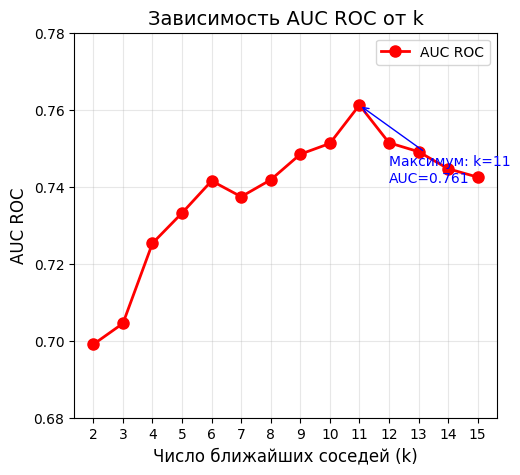

In [ ]:
plt.figure(figsize=(12, 5))

# График AUC ROC
plt.subplot(1, 2, 1)
plt.plot(neighbors_range, roc, marker='o', linestyle='-',
         linewidth=2, markersize=8, color='red', label='AUC ROC')
plt.xlabel('Число ближайших соседей (k)', fontsize=12)
plt.ylabel('AUC ROC', fontsize=12)
plt.title('Зависимость AUC ROC от k', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(neighbors_range)
plt.ylim(0.68, 0.78)  # Типичный диапазон для этого датасета
plt.legend()

# Находим максимум
max_auc = max(roc)
max_neighbor = neighbors_range[roc.index(max_auc)]

plt.annotate(f'Максимум: k={max_neighbor}\nAUC={max_auc:.3f}',
             xy=(max_neighbor, max_auc),
             xytext=(max_neighbor+1, max_auc-0.02),
             arrowprops=dict(arrowstyle='->', color='blue'),
             fontsize=10,
             color='blue')
